In [1]:
# ! pip install tensorflow
# ! pip install  LSTM


In [2]:
# ! pip install keras-tuner
# ! pip install tensorboard

In [3]:
import pandas as pd

import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv('feature_eng/stock_data_with_features_removed_correlated.csv')

In [5]:
df

,Volume,future_returns_5days,future_return_rank,MA_50,Dist_to_MA50,Dist_to_MA200,Golden_Cross,ma_ratio,volatility_5,volatility_20,...,volume_ratio,GK_Volatility,CLV,Daily_Return_CrossRank,RSI_14_CrossRank,Dist_to_MA50_CrossRank,GK_Volatility_CrossRank,target,Date,Ticker
0,160310.0,-0.062554,0.08,608.229597,0.211819,0.125994,0,0.929176,10.154122,29.006881,...,1.186884,0.034643,-0.543182,0.62,0.48,0.90,0.63,-1.0,2012-02-22,ABB.NS
1,521114.0,-0.071999,0.05,612.992942,0.218614,0.141172,0,0.936451,8.645106,25.641833,...,3.392213,0.147192,-0.654093,0.83,0.38,0.93,1.00,-1.0,2012-02-23,ABB.NS
2,452591.0,-0.006580,0.42,617.030356,0.144973,0.079565,0,0.942873,20.440568,23.802254,...,2.702326,0.028703,-0.672002,0.01,0.06,0.76,0.67,0.0,2012-02-24,ABB.NS
3,284882.0,-0.039432,0.06,621.451631,0.145269,0.087983,0,0.949981,20.028408,21.174475,...,1.617969,0.034539,0.482296,0.91,0.18,0.90,0.72,-1.0,2012-02-27,ABB.NS
4,196333.0,-0.013540,0.52,625.840492,0.117405,0.069389,0,0.957029,20.607502,19.947068,...,1.091947,0.028874,-0.798816,0.02,0.12,0.74,0.75,0.0,2012-02-28,ABB.NS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
341286,6563617.0,-0.008424,0.09,100.950800,-0.082821,-0.181772,0,0.892113,0.700371,2.795128,...,1.045805,0.013406,-0.798890,0.52,0.31,0.07,0.85,-1.0,2025-12-17,ZEEL.NS
341287,9312385.0,0.008068,0.43,100.512600,-0.099814,-0.200162,0,0.888525,1.442107,3.053945,...,1.416077,0.020399,-0.607141,0.03,0.06,0.05,0.95,0.0,2025-12-18,ZEEL.NS
341288,9262270.0,0.002320,0.56,100.140200,-0.095967,-0.199557,0,0.885414,1.468372,3.250974,...,1.348708,0.015890,-0.741630,0.24,0.04,0.02,0.85,0.0,2025-12-19,ZEEL.NS
341289,7192902.0,-0.024369,0.20,99.781600,-0.078788,-0.187294,0,0.882214,1.089288,3.294822,...,1.040308,0.014908,-0.219515,0.80,0.10,0.03,0.86,-1.0,2025-12-22,ZEEL.NS


In [6]:
df['target'].value_counts()

target
 1.0    119450
-1.0    112626
 0.0    109215
Name: count, dtype: int64

In [7]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(['Ticker', 'Date']).reset_index(drop=True)

In [8]:
target_mapping = {-1.0: 0, 0.0: 1, 1.0: 2}
df['target_mapped'] = df['target'].map(target_mapping)

In [9]:
meta_cols = ['Date', 'Ticker', 'target', 'target_mapped']
feature_cols = [col for col in df.columns if col not in meta_cols]

In [10]:
unique_dates = df['Date'].sort_values().unique()

In [11]:
total_rows = len(df)

In [12]:
train_cut =int(total_rows * 0.7)
val_cut = int(total_rows * 0.85)

In [13]:
train_df = df.iloc[:train_cut].copy()
val_df = df.iloc[train_cut:val_cut].copy()
test_df = df.iloc[val_cut:].copy()


In [14]:
scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
val_df[feature_cols] = scaler.transform(val_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

In [15]:
def create_sequences(data, feature_cols, target_col, time_steps):
    X, y = [], []
    for ticker, group in data.groupby('Ticker'):
        group_features = group[feature_cols].values
        group_target = group[target_col].values
        
        for i in range(len(group) - time_steps):
            X.append(group_features[i : (i + time_steps)])
            y.append(group_target[i + time_steps])
            
    return np.array(X), np.array(y)

In [16]:
TIME_STEPS = 10

In [17]:
print("\nBuilding 3D time-series sequences...")
X_train, y_train = create_sequences(train_df, feature_cols, 'target_mapped', TIME_STEPS)
X_val, y_val = create_sequences(val_df, feature_cols, 'target_mapped', TIME_STEPS) # NEW
X_test, y_test = create_sequences(test_df, feature_cols, 'target_mapped', TIME_STEPS)

# One-Hot Encode the labels
y_train_cat = to_categorical(y_train, num_classes=3)
y_val_cat = to_categorical(y_val, num_classes=3) # NEW
y_test_cat = to_categorical(y_test, num_classes=3)


Building 3D time-series sequences...


In [18]:
X_train.shape, y_train_cat.shape, X_val.shape, y_val_cat.shape, X_test.shape, y_test_cat.shape

((238203, 10, 34),
 (238203, 3),
 (51041, 10, 34),
 (51041, 3),
 (51044, 10, 34),
 (51044, 3))

In [20]:
import keras_tuner as kt
from tensorflow.keras.regularizers import l1_l2

def build_model(hp):
    # Define your regularization outside or inside
    reg = l1_l2(l1=1e-5, l2=1e-4)
    
    model = Sequential()
    
    # 1. First LSTM Layer
    model.add(LSTM(
        units=hp.Int('units_1', min_value=32, max_value=128, step=32),
        return_sequences=True,
        input_shape=(X_train.shape[1], X_train.shape[2]),
        kernel_regularizer=reg,
        recurrent_regularizer=reg
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_1', 0.2, 0.4)))
    
    # 2. Second LSTM Layer
    model.add(LSTM(
        units=hp.Int('units_2', min_value=16, max_value=64, step=16),
        return_sequences=False,
        kernel_regularizer=reg,
        recurrent_regularizer=reg
    ))
    model.add(BatchNormalization())
    model.add(Dropout(hp.Float('dropout_2', 0.2, 0.4)))
    
    # 3. Dense Layer
    model.add(Dense(
        units=hp.Int('dense_units', 8, 32, step=8),
        activation='relu',
        kernel_regularizer=reg
    ))
    
    # 4. Output Layer
    model.add(Dense(3, activation='softmax'))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
       
    )
    return model

# Initialize the Tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different models to try
    executions_per_trial=1,
    directory='tuner_results',
    project_name='lstm_stock_optimization'
)

# Run the search
tuner.search(X_train, y_train_cat, epochs=10, validation_data=(X_val, y_val_cat),callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3)])

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal Units in layer 1: {best_hyperparameters.get('units_1')}")
print(f"Optimal Learning Rate: {best_hyperparameters.get('learning_rate')}")

Reloading Tuner from tuner_results/lstm_stock_optimization/tuner0.json
Optimal Units in layer 1: 128
Optimal Learning Rate: 0.001


/opt/anaconda3/envs/trade/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/opt/anaconda3/envs/trade/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 30 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:

# from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# reg = l1_l2(l1=1e-5, l2=1e-4)

# model = Sequential([
#     # First LSTM Layer
#     LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]),kernel_regularizer=reg,     # Penalizes input weights
#         recurrent_regularizer=reg),  # Penalizes recurrent weights
#     BatchNormalization(),
#     Dropout(0.3),
    
#     # Second LSTM Layer
#     LSTM(units=32, return_sequences=False,kernel_regularizer=reg,
#     recurrent_regularizer=reg),
#     BatchNormalization(),
#     Dropout(0.3),
    
    
#     # Dense Classifier Layers
#     Dense(16, activation='relu',kernel_regularizer=reg),
#     Dense(3, activation='softmax'), # Softmax outputs probabilities for Sell/Hold/Buy

# ])

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# model.summary()

In [21]:
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=7, 
    restore_best_weights=True,
    verbose=1
)

In [25]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [27]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,        # Multiply current LR by 0.5 (cut in half)
    patience=3,        # Wait 3 epochs before reducing
    min_lr=1e-6,       # Never let the LR go below this number
    verbose=1
)

In [28]:
print("\nStarting Training...")
history = best_model.fit(
    X_train, y_train_cat,
    epochs=50, 
    batch_size=128, 
    validation_data=(X_val, y_val_cat), 
    callbacks=[reduce_lr, early_stopping], # <--- Added reduce_lr here
    verbose=1
)


Starting Training...
Epoch 1/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 57s 29ms/step - accuracy: 0.7017 - loss: 0.6921 - val_accuracy: 0.7120 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 2/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.7053 - loss: 0.6812 - val_accuracy: 0.7088 - val_loss: 0.6699 - learning_rate: 0.0010
Epoch 3/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.7064 - loss: 0.6785 - val_accuracy: 0.7112 - val_loss: 0.6637 - learning_rate: 0.0010
Epoch 4/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 52s 28ms/step - accuracy: 0.7073 - loss: 0.6756 - val_accuracy: 0.7086 - val_loss: 0.6690 - learning_rate: 0.0010
Epoch 5/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.7069 - loss: 0.6747 - val_accuracy: 0.7137 - val_loss: 0.6628 - learning_rate: 0.0010
Epoch 6/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 47s 25ms/step - accuracy: 0.7071 - loss: 0.6739 - val_accuracy: 0.7083 - val_loss: 0.6676 - learning_rate: 0.0010
Epoch 7/50
1861/1861 ━━━━━━━━━━━━━━━━━━━━ 

Final Test Accuracy: 71.80%


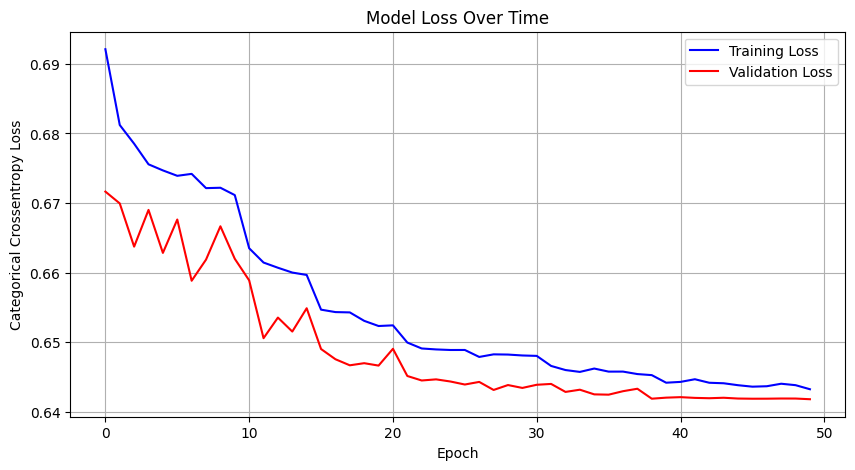

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step

Sample Predictions vs Actual on Test Set:
Predicted: Hold (60.2% confidence) | Actual: Sell
Predicted: Hold (50.5% confidence) | Actual: Sell
Predicted: Sell (81.7% confidence) | Actual: Sell
Predicted: Sell (83.0% confidence) | Actual: Sell
Predicted: Sell (95.8% confidence) | Actual: Sell
Predicted: Sell (93.4% confidence) | Actual: Sell
Predicted: Sell (82.5% confidence) | Actual: Sell
Predicted: Sell (98.3% confidence) | Actual: Sell
Predicted: Sell (95.3% confidence) | Actual: Sell
Predicted: Sell (62.0% confidence) | Actual: Hold
Predicted: Sell (48.0% confidence) | Actual: Hold
Predicted: Buy  (90.7% confidence) | Actual: Buy
Predicted: Buy  (47.9% confidence) | Actual: Buy
Predicted: Buy  (81.7% confidence) | Actual: Buy
Predicted: Hold (54.6% confidence) | Actual: Hold
Predicted: Sell (51.3% confidence) | Actual: Buy
Predicted: Buy  (97.2% confidence) | Actual: Buy
Predicted: Buy  (86.3% confidence) | Actual: Buy
Predicted: Buy  (90.1% co

In [29]:
loss, accuracy = best_model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Final Test Accuracy: {accuracy*100:.2f}%")


# Plot Training vs Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='red')
plt.title('Model Loss Over Time')
plt.ylabel('Categorical Crossentropy Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)
plt.show()

# Generate sample predictions
predictions = best_model.predict(X_test[:100])
predicted_classes = np.argmax(predictions, axis=1)

print("\nSample Predictions vs Actual on Test Set:")
for i in range(100):
    confidence = np.max(predictions[i]) * 100
    pred_label = "Sell" if predicted_classes[i] == 0 else "Hold" if predicted_classes[i] == 1 else "Buy"
    actual_label = "Sell" if y_test[i] == 0 else "Hold" if y_test[i] == 1 else "Buy"
    print(f"Predicted: {pred_label:<4} ({confidence:.1f}% confidence) | Actual: {actual_label}")

1596/1596 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step

FINAL MACRO CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Sell       0.77      0.78      0.78     17198
        Hold       0.56      0.59      0.58     15505
         Buy       0.81      0.76      0.79     18341

    accuracy                           0.72     51044
   macro avg       0.72      0.71      0.71     51044
weighted avg       0.72      0.72      0.72     51044



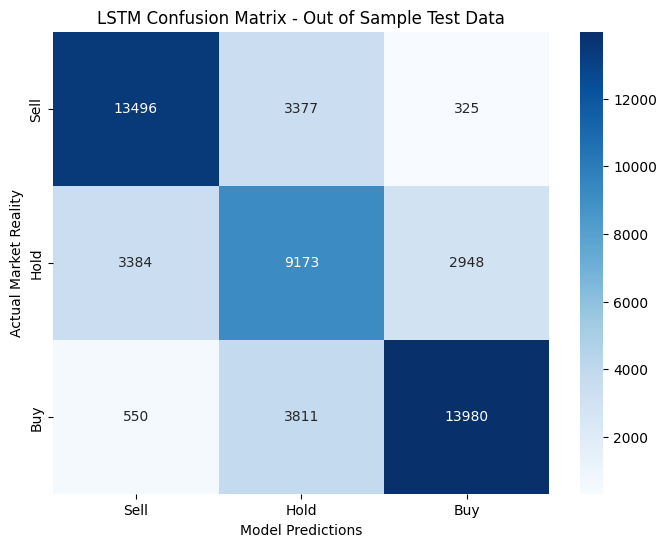

In [30]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get predictions for the ENTIRE test set, not just the first 10
full_predictions = best_model.predict(X_test)
full_predicted_classes = np.argmax(full_predictions, axis=1)

# 2. Print the Classification Report
print("\n" + "="*50)
print("FINAL MACRO CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, full_predicted_classes, target_names=['Sell', 'Hold', 'Buy']))

# 3. Plot a beautiful Confusion Matrix
cm = confusion_matrix(y_test, full_predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Sell', 'Hold', 'Buy'], 
            yticklabels=['Sell', 'Hold', 'Buy'])
plt.ylabel('Actual Market Reality')
plt.xlabel('Model Predictions')
plt.title('LSTM Confusion Matrix - Out of Sample Test Data')
plt.show()

In [31]:
import joblib

# 1. Save the LSTM Model (Use .keras format, the modern standard)
best_model.save("quant_lstm_model.keras")

# 2. Save the Scaler
joblib.dump(scaler, "quant_scaler.pkl")

# 3. Save the exact list of feature columns (CRITICAL for the API to maintain order)
joblib.dump(feature_cols, "feature_columns.pkl")

print("All artifacts successfully saved to disk!")

All artifacts successfully saved to disk!
